# POC SOC Triage — 02 : Feature Engineering

**Objectif** : transformer les données brutes (`incidents_dataset.csv`, `TI_database.csv`, `CMDB.csv`, `Sandbox.csv`) en un tableau de features numériques utilisables par un modèle ML.

**Output** : `data/features_ml.csv` — 30 000 incidents × ~45 features, prêt pour le `03_`.

---

## Qu'est-ce que le feature engineering ?

Un modèle ML ne comprend que des **nombres**. On doit donc convertir toutes les informations textuelles ou catégorielles (titre d'alerte, grade, techniques MITRE…) en colonnes numériques. C'est ce qu'on appelle le **feature engineering**.

Chaque colonne numérique qu'on crée s'appelle une **feature** (ou variable explicative). Plus une feature est corrélée au grade de l'incident (TP/BP/FP), plus elle sera utile pour le modèle.

---

## Plan des familles de features

| # | Famille | Source |
|---|---------|--------|
| 1 | **Alerte brute** — compteurs et target encoding par titre/catégorie | incidents_dataset |
| 2 | **Temporelle** — heure, jour, durée, encodage cyclique | incidents_dataset |
| 3 | **Propagation** — ratios comptes/devices, score d'étendue | incidents_dataset |
| 4 | **Threat Intelligence** — score TI, blocklist, actor type | TI_database |
| 5 | **CMDB device** — criticité asset, patch lag, vulnérabilités | CMDB |
| 6 | **CMDB user** — compte privilégié, MFA, tentatives de login | CMDB |
| 7 | **Sandbox** — comportements malveillants du fichier analysé | Sandbox |
| 8 | **Historique SOC** — taux FP/TP historiques par détecteur | incidents_dataset |
| 9 | **MITRE ATT&CK** — tactiques présentes, encodées en binaire | incidents_dataset |
| 10 | **Contexte incident** — présence d'entités, famille de malware | incidents_dataset |


## 0. Configuration et chargement

In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR    = Path('data')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Librairies chargées ✓")

Librairies chargées ✓


In [270]:
# ── Chargement des 4 fichiers produits par le 01_ ─────────────────────────────

df      = pd.read_csv(DATA_DIR / 'incidents_dataset.csv',
                      parse_dates=['first_seen', 'last_seen'],
                      dtype={'sample_device_id': str})

cmdb    = pd.read_csv(DATA_DIR / 'CMDB.csv', dtype={'device_id': str})
ti      = pd.read_csv(DATA_DIR / 'TI_database.csv')
sandbox = pd.read_csv(DATA_DIR / 'Sandbox.csv')

print(f"Incidents chargés    : {len(df):,} lignes × {df.shape[1]} colonnes")
print(f"CMDB                 : {len(cmdb):,} lignes (devices + users)")
print(f"TI_database          : {len(ti):,} IOCs")
print(f"Sandbox              : {len(sandbox):,} fichiers analysés")
print()
print("Distribution de la cible (IncidentGrade) :")
print(df['IncidentGrade'].value_counts())

Incidents chargés    : 30,000 lignes × 56 colonnes
CMDB                 : 7,154 lignes (devices + users)
TI_database          : 708 IOCs
Sandbox              : 1,547 fichiers analysés

Distribution de la cible (IncidentGrade) :
IncidentGrade
BenignPositive    13869
FalsePositive      9514
TruePositive       6617
Name: count, dtype: int64


## 1. Exploration rapide des données (EDA)

Avant de construire des features, on regarde les distributions clés.
C'est toujours la première étape en ML : comprendre les données avant de les transformer.


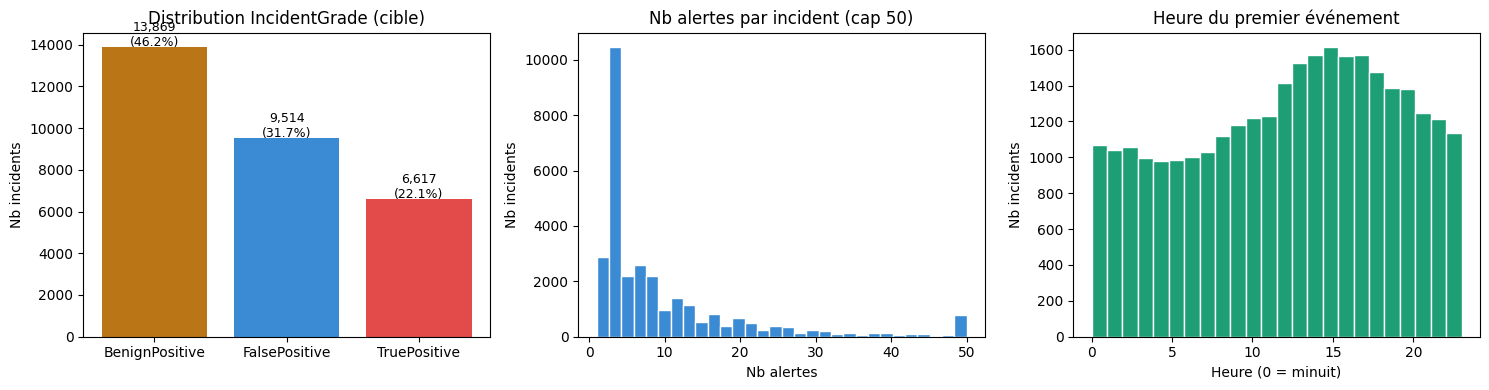

Figure sauvegardée : eda_distributions.png


In [271]:
# ── Distribution de la cible ───────────────────────────────────────────────────
# La cible (IncidentGrade) est ce qu'on veut prédire.
# On vérifie que les 3 classes (TP/BP/FP) sont suffisamment représentées.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

grade_counts = df['IncidentGrade'].value_counts()
colors = {'TruePositive': '#E24B4A', 'BenignPositive': '#BA7517', 'FalsePositive': '#3B8BD4'}

bars = axes[0].bar(grade_counts.index, grade_counts.values,
                   color=[colors.get(g, 'gray') for g in grade_counts.index])
axes[0].set_title('Distribution IncidentGrade (cible)')
axes[0].set_ylabel('Nb incidents')
for bar, val in zip(bars, grade_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=9)

# Nombre d'alertes par incident
axes[1].hist(df['nb_alerts'].clip(upper=50), bins=30,
             color='#3B8BD4', edgecolor='white')
axes[1].set_title("Nb alertes par incident (cap 50)")
axes[1].set_xlabel("Nb alertes")
axes[1].set_ylabel("Nb incidents")

# Heure du premier événement
axes[2].hist(df['hour_of_day'], bins=24, color='#1D9E75', edgecolor='white')
axes[2].set_title("Heure du premier événement")
axes[2].set_xlabel("Heure (0 = minuit)")
axes[2].set_ylabel("Nb incidents")

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : eda_distributions.png")

In [272]:
# ── Taux de nulls dans incidents_dataset ──────────────────────────────────────
# Certaines colonnes sont peu renseignées dans GUIDE — c'est une réalité du dataset,
# pas un bug. On les identifie pour décider comment les traiter.

missing = df.isnull().mean().sort_values(ascending=False)
missing_pct = missing[missing > 0.01] * 100
print("Colonnes avec > 1% de valeurs manquantes :")
print(missing_pct.round(1).to_string())

Colonnes avec > 1% de valeurs manquantes :
top_action_granular    97.5
action_grouped         97.5
threat_family          97.2
antispam_direction     84.1
max_suspicion          73.3
last_verdict           61.1
mitre_techniques       55.0


## 2. Initialisation du tableau de features

On crée un DataFrame `feat` avec une ligne par incident.
On y ajoutera les features famille par famille.


In [273]:
# ── Base du tableau de features ────────────────────────────────────────────────
# On part avec les colonnes d'identification (IncidentId, OrgId)
# et la cible (IncidentGrade) qu'on supprimera à la fin.

feat = df[['IncidentId', 'OrgId', 'IncidentGrade']].copy()

print(f"Tableau de features initialisé : {feat.shape[0]:,} lignes")

Tableau de features initialisé : 30,000 lignes


## 3. Famille 1 — Alerte brute

**Idée** : un incident avec 200 alertes de type "Ransomware détecté" est très différent
d'un incident avec 1 alerte de type "Scan réseau détecté".

On récupère les compteurs bruts (nb alertes, nb détecteurs…) et on calcule
le **taux historique TP/BP/FP** pour chaque titre d'alerte et chaque catégorie.

> ⚠️ **Note sur le data leakage** : ces taux sont calculés sur l'ensemble du dataset.
> Dans le `03_`, il faudra les recalculer uniquement sur le train set pour éviter de
> "tricher" en utilisant des informations du futur. On le note ici pour ne pas l'oublier.


In [274]:
# ── Compteurs bruts de l'incident ─────────────────────────────────────────────
# Ces colonnes viennent directement d'incidents_dataset — elles comptent
# les différents types d'entités et d'alertes dans chaque incident.

feat['nb_alerts']       = df['nb_alerts']        # nb alertes agrégées dans l'incident
feat['nb_evidences']    = df['nb_evidences']      # nb lignes brutes dans les alertes
feat['nb_categories']   = df['nb_categories']     # nb catégories MITRE distinctes
feat['nb_detectors']    = df['nb_detectors']      # nb détecteurs différents déclenchés
feat['nb_entity_types'] = df['nb_entity_types']   # nb types d'entités (IP, device, compte…)

print("Compteurs bruts ajoutés :", ['nb_alerts','nb_evidences','nb_categories',
                                     'nb_detectors','nb_entity_types'])

Compteurs bruts ajoutés : ['nb_alerts', 'nb_evidences', 'nb_categories', 'nb_detectors', 'nb_entity_types']


In [275]:
# ── Target encoding par titre d'alerte ────────────────────────────────────────
# Un titre d'alerte comme "Emotet malware detected" aura historiquement
# un taux TP élevé, tandis que "Network scan detected" aura un taux FP élevé.
# On encode cette information statistique pour chaque titre d'alerte.
#
# Smoothing bayésien (M=10) :
# Pour un titre RARE (ex: vu 2 fois), on ne fait pas confiance au taux observé.
# On "tire" le taux vers la moyenne globale pour éviter les valeurs extrêmes.
# Formule : (n × taux_observé + M × taux_global) / (n + M)
# Exemple : 1 TP sur 1 incident → taux = (1×1.0 + 10×0.22) / (1+10) = 0.29 (pas 1.0)

M = 10
global_tp = (df['IncidentGrade'] == 'TruePositive').mean()
global_bp = (df['IncidentGrade'] == 'BenignPositive').mean()
global_fp = (df['IncidentGrade'] == 'FalsePositive').mean()

# Calcul des taux pour chaque titre d'alerte
grade_dummies = pd.get_dummies(df['IncidentGrade'])
df_enc = pd.concat([df[['top_alert_title', 'top_category', 'top_detector']], grade_dummies], axis=1)

counts_title = df_enc['top_alert_title'].value_counts().rename('n')
stats_title  = df_enc.groupby('top_alert_title')[['TruePositive','BenignPositive','FalsePositive']].mean()
stats_title  = stats_title.join(counts_title)

for col, global_rate in [('TruePositive', global_tp), ('BenignPositive', global_bp), ('FalsePositive', global_fp)]:
    stats_title[col] = (stats_title['n'] * stats_title[col] + M * global_rate) / (stats_title['n'] + M)

stats_title = stats_title.drop(columns='n')
stats_title.columns = ['alert_title_tp_rate', 'alert_title_bp_rate', 'alert_title_fp_rate']

# Taux par catégorie (peu de valeurs distinctes → pas besoin de smoothing)
stats_cat = df_enc.groupby('top_category')[['TruePositive','BenignPositive','FalsePositive']].mean()
stats_cat.columns = ['category_tp_rate', 'category_bp_rate', 'category_fp_rate']

# Merge dans le tableau de features
feat = feat.merge(df[['IncidentId','top_alert_title','top_category']], on='IncidentId', how='left')
feat = feat.merge(stats_title, left_on='top_alert_title', right_index=True, how='left')
feat = feat.merge(stats_cat,   left_on='top_category',   right_index=True, how='left')

# Valeur par défaut pour les titres/catégories non vus : taux global
for col, val in [('alert_title_tp_rate', global_tp), ('alert_title_bp_rate', global_bp),
                 ('alert_title_fp_rate', global_fp), ('category_tp_rate', global_tp),
                 ('category_bp_rate', global_bp),    ('category_fp_rate', global_fp)]:
    feat[col] = feat[col].fillna(val)

# Nettoyage des colonnes de jointure
feat = feat.drop(columns=['top_alert_title', 'top_category'])

print("Target encoding ajouté ✓")
print("Taux TP moyen par grade (validation du signal) :")
print(feat.groupby('IncidentGrade')['alert_title_tp_rate'].mean().round(3))

Target encoding ajouté ✓
Taux TP moyen par grade (validation du signal) :
IncidentGrade
BenignPositive    0.183
FalsePositive     0.156
TruePositive      0.441
Name: alert_title_tp_rate, dtype: float64


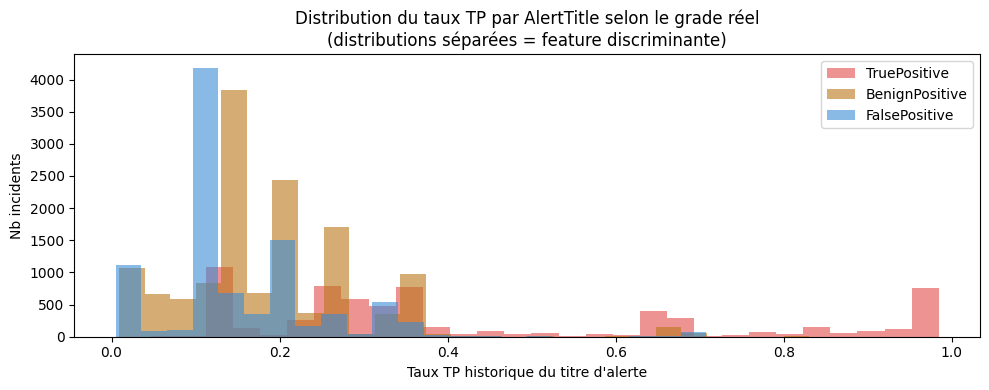

In [276]:
# ── Visualisation du target encoding ──────────────────────────────────────────
# Si les distributions sont bien séparées selon le grade réel,
# la feature est discriminante — le modèle pourra s'en servir.

fig, ax = plt.subplots(figsize=(10, 4))
for grade, color in [('TruePositive','#E24B4A'), ('BenignPositive','#BA7517'), ('FalsePositive','#3B8BD4')]:
    subset = feat[feat['IncidentGrade'] == grade]['alert_title_tp_rate']
    ax.hist(subset, bins=30, alpha=0.6, label=grade, color=color)
ax.set_xlabel("Taux TP historique du titre d'alerte")
ax.set_ylabel("Nb incidents")
ax.set_title("Distribution du taux TP par AlertTitle selon le grade réel\n"
             "(distributions séparées = feature discriminante)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_target_encoding.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Famille 2 — Features temporelles

**Idée** : les attaques se produisent souvent la nuit ou le week-end (quand le SOC est réduit).
Les faux positifs sont sur-représentés en heures ouvrées (outils légitimes, scans planifiés).

On utilise des colonnes déjà calculées par le `01_` et on ajoute un **encodage cyclique** :
- Problème classique : 23h et 0h sont numériquement distants (23 vs 0) mais temporellement adjacents.
- Solution : projeter l'heure sur un cercle avec `sin` et `cos` — 23h et 0h se retrouvent proches.


In [277]:
# ── Features temporelles depuis incidents_dataset ─────────────────────────────
# Ces colonnes ont été calculées par le 01_ — on les copie directement.

feat['hour_of_day']          = df['hour_of_day'].fillna(12)       # heure (0-23), défaut midi
feat['day_of_week']          = df['day_of_week'].fillna(0)        # jour (0=lundi, 6=dimanche)
feat['is_weekend']           = df['is_weekend'].fillna(0).astype(int)
feat['is_business_hours']    = df['is_business_hours'].fillna(1).astype(int)
feat['is_after_midnight']    = df['is_after_midnight'].fillna(0).astype(int)  # 0h-5h (attaque planifiée)
feat['incident_duration_min'] = df['incident_duration_minutes'].fillna(0).clip(upper=10080)

# ── Débit d'alertes ────────────────────────────────────────────────────────────
# Nb alertes par heure de durée de l'incident.
# Un débit très élevé = burst soudain (ransomware, scan massif).
# Un débit faible sur longue durée = activité discrète (APT patient).
feat['alert_rate_per_hour'] = (
    df['nb_alerts'] / (df['incident_duration_minutes'] / 60 + 0.01)
).fillna(0).clip(upper=1000)

# ── Encodage cyclique (sin/cos) ────────────────────────────────────────────────
# Résout le problème de la "coupure" entre 23h et 0h, et entre dimanche et lundi.
# Le modèle voit l'heure comme une position sur un cercle, pas comme un nombre linéaire.
feat['hour_sin'] = np.sin(2 * np.pi * feat['hour_of_day'] / 24)
feat['hour_cos'] = np.cos(2 * np.pi * feat['hour_of_day'] / 24)
feat['day_sin']  = np.sin(2 * np.pi * feat['day_of_week'] / 7)
feat['day_cos']  = np.cos(2 * np.pi * feat['day_of_week'] / 7)

print("Features temporelles ajoutées :")
print([c for c in feat.columns if c not in ['IncidentId','OrgId','IncidentGrade']])

Features temporelles ajoutées :
['nb_alerts', 'nb_evidences', 'nb_categories', 'nb_detectors', 'nb_entity_types', 'alert_title_tp_rate', 'alert_title_bp_rate', 'alert_title_fp_rate', 'category_tp_rate', 'category_bp_rate', 'category_fp_rate', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_business_hours', 'is_after_midnight', 'incident_duration_min', 'alert_rate_per_hour', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']


## 5. Famille 3 — Propagation

**Idée** : un incident qui touche beaucoup de devices, comptes et IPs différents
est probablement une vraie attaque en cours de propagation, pas un faux positif.

On construit des **ratios** plus discriminants que les compteurs bruts.


In [278]:
# ── Ratios de propagation ──────────────────────────────────────────────────────

# accounts_per_device : ratio comptes touchés / devices touchés
# Un attaquant qui se propage utilise plusieurs comptes sur plusieurs machines.
# +1 au dénominateur pour éviter la division par zéro.
feat['accounts_per_device'] = (
    df['nb_unique_accounts'] / (df['nb_unique_devices'] + 1)
).fillna(0).clip(upper=20)

# ips_per_hour : densité d'IPs distinctes dans le temps
# Un scan réseau ou un mouvement latéral rapide = beaucoup d'IPs en peu de temps.
feat['ips_per_hour'] = (
    df['nb_unique_ips'] / (df['incident_duration_minutes'] / 60 + 0.1)
).fillna(0).clip(upper=100)

# alerts_per_detector : nb alertes moyennes par détecteur
# Un seul détecteur qui sonne beaucoup = bruit probable (FP).
# Plusieurs détecteurs indépendants qui s'activent = signal convergent (TP probable).
feat['alerts_per_detector'] = (
    df['nb_alerts'] / (df['nb_detectors'] + 1)
).fillna(0).clip(upper=1000)

# spread_score : score de propagation pondéré
# Remplace le flag binaire multi_entity par un score continu plus nuancé.
# Pondérations : device = 2 (compromission physique), account = 1.5 (mouvement latéral),
# IP = 1 (connexion réseau, moins critique seul).
feat['spread_score'] = (
    2.0 * df['nb_unique_devices'].fillna(0) +
    1.5 * df['nb_unique_accounts'].fillna(0) +
    1.0 * df['nb_unique_ips'].fillna(0)
).clip(upper=100)

# ── Features de contexte issues du 01_ ────────────────────────────────────────
# has_impacted_entity : au moins une entité directement impactée dans l'incident
# (EvidenceRole == "Impacted") — signal plus fort que juste "lié à l'incident".
feat['has_impacted_entity']  = df['has_impacted_entity'].fillna(0).astype(int)
feat['nb_impacted_entities'] = df['nb_impacted_entities'].fillna(0).astype(int)

print("Features propagation ajoutées :")
print(['accounts_per_device','ips_per_hour','alerts_per_detector',
       'spread_score','has_impacted_entity','nb_impacted_entities'])
print()
print("Spread score moyen par grade :")
print(feat.groupby('IncidentGrade')['spread_score'].mean().round(2))

Features propagation ajoutées :
['accounts_per_device', 'ips_per_hour', 'alerts_per_detector', 'spread_score', 'has_impacted_entity', 'nb_impacted_entities']

Spread score moyen par grade :
IncidentGrade
BenignPositive    6.50
FalsePositive     6.09
TruePositive      6.90
Name: spread_score, dtype: float64


## 6. Famille 4 — Threat Intelligence (TI)

**Idée** : si l'IP ou le hash associé à un incident est référencé dans une base de réputation
comme malveillant (VirusTotal, blocklists…), c'est un signal fort que l'incident est réel.

Dans ce POC, les scores TI sont simulés de façon cohérente avec le grade réel (cf. `01_`).
En production, ils viendraient de feeds TI externes mis à jour régulièrement.


In [279]:
# ── Séparation de la base TI par type d'IOC ───────────────────────────────────
# La TI contient deux types d'indicateurs : les IPs et les hashes SHA256.
# On les joint séparément sur les colonnes sample_ip et sample_sha256 de l'incident.

ti_ip = (ti[ti['ioc_type'] == 'ip']
         [['ioc_value','ti_score','in_blocklist','nb_sources_flagging','ti_confidence']]
         .rename(columns={'ioc_value':          'sample_ip',
                          'ti_score':           'ip_ti_score',
                          'in_blocklist':       'ip_in_blocklist',
                          'nb_sources_flagging':'ip_nb_sources',
                          'ti_confidence':      'ip_ti_confidence'}))

ti_hash = (ti[ti['ioc_type'] == 'sha256']
           [['ioc_value','ti_score','in_blocklist','nb_sources_flagging','ti_confidence']]
           .rename(columns={'ioc_value':          'sample_sha256',
                            'ti_score':           'hash_ti_score',
                            'in_blocklist':       'hash_in_blocklist',
                            'nb_sources_flagging':'hash_nb_sources',
                            'ti_confidence':      'hash_ti_confidence'}))

# ── Jointure TI ────────────────────────────────────────────────────────────────
feat = feat.merge(df[['IncidentId','sample_ip','sample_sha256']], on='IncidentId', how='left')
feat = feat.merge(ti_ip,   on='sample_ip',   how='left')
feat = feat.merge(ti_hash, on='sample_sha256', how='left')

# Valeur par défaut = 0 : absence de TI = signal neutre (pas nécessairement propre)
for col, default in [('ip_ti_score', 0), ('ip_in_blocklist', 0), ('ip_nb_sources', 0),
                     ('ip_ti_confidence', 0), ('hash_ti_score', 0),
                     ('hash_in_blocklist', 0), ('hash_nb_sources', 0), ('hash_ti_confidence', 0)]:
    feat[col] = feat.get(col, pd.Series(default, index=feat.index)).fillna(default)

# ── Features combinées ─────────────────────────────────────────────────────────
# ti_score_max : meilleur signal TI disponible (IP ou hash).
# Utile quand un seul des deux IOCs est référencé en TI.
feat['ti_score_max']      = feat[['ip_ti_score','hash_ti_score']].max(axis=1)

# ti_score_combined : somme IP + hash.
# Si les deux sont malveillants, le risque est plus élevé qu'un seul.
feat['ti_score_combined'] = feat['ip_ti_score'] + feat['hash_ti_score']

# any_ioc_in_blocklist : au moins un IOC dans une liste de blocage active.
# Signal très fort : menace connue et confirmée.
feat['any_ioc_in_blocklist'] = (
    (feat['ip_in_blocklist'] == 1) | (feat['hash_in_blocklist'] == 1)
).astype(int)

# ── Actor type (nouveau depuis 01_ v2) ─────────────────────────────────────────
# Type d'acteur attribué à l'IOC : APT (espionnage étatique), cybercrime,
# hacktivist, ou unknown (non attribué).
# On encode en binaires pour que le modèle puisse distinguer les types.
ti_actor = (ti[['ioc_value','ioc_type','actor_type']]
            .query("ioc_type == 'ip'")
            .rename(columns={'ioc_value': 'sample_ip',
                             'actor_type': 'ip_actor_type'}))
feat = feat.merge(ti_actor[['sample_ip','ip_actor_type']], on='sample_ip', how='left')

for actor in ['APT', 'cybercrime', 'hacktivist']:
    feat[f'ti_actor_{actor}'] = (feat['ip_actor_type'] == actor).astype(int)
feat = feat.drop(columns=['ip_actor_type'], errors='ignore')

# ── Nettoyage colonnes de jointure ─────────────────────────────────────────────
feat = feat.drop(columns=['sample_ip','sample_sha256'], errors='ignore')

print("Features TI ajoutées :")
print([c for c in feat.columns if 'ti_' in c or 'ioc' in c or 'actor' in c])
print()
print("Score TI max moyen par grade (doit être TP > BP ≈ FP) :")
print(feat.groupby('IncidentGrade')['ti_score_max'].mean().round(2))

Features TI ajoutées :
['ip_ti_score', 'ip_ti_confidence', 'hash_ti_score', 'hash_ti_confidence', 'ti_score_max', 'ti_score_combined', 'any_ioc_in_blocklist', 'ti_actor_APT', 'ti_actor_cybercrime', 'ti_actor_hacktivist']

Score TI max moyen par grade (doit être TP > BP ≈ FP) :
IncidentGrade
BenignPositive    0.24
FalsePositive     0.39
TruePositive      6.79
Name: ti_score_max, dtype: float64


## 7. Famille 5 — CMDB Device (asset)

**Idée** : un incident qui touche un serveur de production critique (Domain Controller)
est bien plus grave que le même incident sur un poste de développement.

Le CMDB (Configuration Management Database) contient les informations sur chaque asset.


In [280]:
# ── Séparation CMDB devices / users ───────────────────────────────────────────
# Le fichier CMDB contient une ligne par entité : soit un device, soit un user.
# On les sépare avant de faire les jointures.
cmdb_dev  = cmdb[cmdb['device_id'].notna()].copy()
cmdb_user = cmdb[cmdb['account_id'].notna()].copy()
print(f"CMDB : {len(cmdb_dev)} devices | {len(cmdb_user)} users")

CMDB : 244 devices | 6910 users


In [281]:
# ── Jointure CMDB Device ────────────────────────────────────────────────────────
# On joint sur sample_device_id — en excluant les "NET-" qui ne sont pas
# de vrais devices (incidents sans entité identifiée).
#
# Normalisation des IDs : DeviceId dans GUIDE est un nombre flottant (ex: 1234567.0).
# Pandas peut le lire comme "1234567.0" dans un fichier et "1234567" dans l'autre —
# ce petit ".0" suffit à casser la jointure. On normalise les deux côtés.

def normalize_device_id(series):
    """Retire le .0 flottant si présent : "123.0" → "123", "DEV_001" reste "DEV_001"."""
    return (series
            .astype(str)
            .str.strip()
            .str.replace(r'\.0$', '', regex=True)
            .replace('nan', pd.NA))

df_dev_ids = df[['IncidentId','sample_device_id']].copy()
df_dev_ids['sample_device_id'] = normalize_device_id(df_dev_ids['sample_device_id'])

# Exclure les NET- (incidents sans device réel)
df_dev_ids = df_dev_ids[~df_dev_ids['sample_device_id'].str.startswith('NET-', na=True)]
df_dev_ids = df_dev_ids.dropna(subset=['sample_device_id'])

# Normaliser aussi le côté CMDB
cmdb_dev_norm = cmdb_dev.copy()
cmdb_dev_norm['device_id'] = normalize_device_id(cmdb_dev_norm['device_id'])

# Diagnostic avant jointure
n_matches = len(set(df_dev_ids['sample_device_id']) & set(cmdb_dev_norm['device_id'].dropna()))
print(f"Incidents avec device réel : {len(df_dev_ids):,}")
print(f"IDs uniques en commun      : {n_matches:,}")
if len(df_dev_ids) > 0:
    print(f"Exemple sample_device_id   : {df_dev_ids['sample_device_id'].iloc[0]}")
if len(cmdb_dev_norm) > 0:
    print(f"Exemple device_id CMDB     : {cmdb_dev_norm['device_id'].iloc[0]}")

feat_dev = df_dev_ids.merge(
    cmdb_dev_norm[['device_id','asset_criticality','sensitivity_score',
              'is_internet_exposed','patch_level','days_since_last_patch',
              'nb_vulnerabilities','is_domain_controller','network_zone',
              'last_incident_days_ago']],
    left_on='sample_device_id', right_on='device_id', how='left'
)

# ── Encodage de la criticité asset ────────────────────────────────────────────
# CRITICAL=4, HIGH=3, MEDIUM=2, LOW=1, inconnu=0
crit_map = {'CRITICAL': 4, 'HIGH': 3, 'MEDIUM': 2, 'LOW': 1}
feat_dev['asset_criticality_score'] = feat_dev['asset_criticality'].map(crit_map).fillna(0)

# ── Patch risk : délai de patching → risque de vulnérabilité exploitable ───────
# "Up-to-date"=0, "Minor-lag"=1, "Critical-lag"=2
patch_map = {'Up-to-date': 0, 'Minor-lag': 1, 'Critical-lag': 2}
feat_dev['asset_patch_risk'] = feat_dev['patch_level'].map(patch_map).fillna(1)

# ── Zone réseau : plus l'asset est exposé, plus le risque est élevé ───────────
zone_map = {'DMZ': 2, 'CORP': 1, 'ISOLATED': 0}
feat_dev['asset_network_zone_risk'] = feat_dev['network_zone'].map(zone_map).fillna(1)

# ── Score de risque asset global ───────────────────────────────────────────────
# Combine criticité, patch risk et exposition Internet en un seul score.
feat_dev['asset_risk_score'] = (
    feat_dev['asset_criticality_score'] * 2 +
    feat_dev['asset_patch_risk'] +
    feat_dev.get('is_internet_exposed', pd.Series(0, index=feat_dev.index)).fillna(0)
)

# ── Merge dans le tableau principal ────────────────────────────────────────────
asset_cols = ['IncidentId','asset_criticality_score','asset_patch_risk',
              'asset_network_zone_risk','asset_risk_score',
              'days_since_last_patch','nb_vulnerabilities',
              'is_domain_controller','last_incident_days_ago',
              'is_internet_exposed']

feat = feat.merge(feat_dev[asset_cols], on='IncidentId', how='left')

# Valeur par défaut = 0 (inconnu = neutre)
for col in ['asset_criticality_score','asset_patch_risk','asset_network_zone_risk',
            'asset_risk_score','days_since_last_patch','nb_vulnerabilities',
            'is_domain_controller','last_incident_days_ago','is_internet_exposed']:
    feat[col] = feat[col].fillna(0)

print("Features CMDB device ajoutées :")
print(['asset_criticality_score','asset_patch_risk','asset_network_zone_risk',
       'asset_risk_score','days_since_last_patch','nb_vulnerabilities',
       'is_domain_controller','last_incident_days_ago','is_internet_exposed'])
print()
print("Criticité asset moyenne par grade :")
print(feat.groupby('IncidentGrade')['asset_criticality_score'].mean().round(2))

Incidents avec device réel : 30,000
IDs uniques en commun      : 244
Exemple sample_device_id   : 98799
Exemple device_id CMDB     : 98799
Features CMDB device ajoutées :
['asset_criticality_score', 'asset_patch_risk', 'asset_network_zone_risk', 'asset_risk_score', 'days_since_last_patch', 'nb_vulnerabilities', 'is_domain_controller', 'last_incident_days_ago', 'is_internet_exposed']

Criticité asset moyenne par grade :
IncidentGrade
BenignPositive    1.01
FalsePositive     1.01
TruePositive      1.02
Name: asset_criticality_score, dtype: float64


## 8. Famille 6 — CMDB User (risque utilisateur)

**Idée** : un compte administrateur ou executive ciblé dans un incident est un signal
plus grave que le même incident sur un compte utilisateur standard.

Les nouveaux champs du `01_` v2 (MFA, tentatives de login, mismatch géographique)
enrichissent considérablement ce profil de risque.


In [282]:
# ── Jointure CMDB User ─────────────────────────────────────────────────────────
df_user_ids = df[['IncidentId','sample_account']].dropna(subset=['sample_account'])

# Convertir sample_account en numérique pour la jointure (account_id est un nombre)
df_user_ids = df_user_ids.copy()
df_user_ids['_account_key'] = pd.to_numeric(df_user_ids['sample_account'], errors='coerce')

feat_user = df_user_ids.merge(
    cmdb_user[['account_id','user_criticality','is_privileged',
               'account_status','last_login_days',
               'MFA_enabled','nb_failed_logins_7d','login_country_mismatch']],
    left_on='_account_key', right_on='account_id', how='left'
)[['IncidentId','user_criticality','is_privileged','account_status',
   'last_login_days','MFA_enabled','nb_failed_logins_7d','login_country_mismatch']]

feat = feat.merge(feat_user, on='IncidentId', how='left')

# ── Encodage du risque utilisateur ────────────────────────────────────────────
user_crit_map = {'CRITICAL': 4, 'HIGH': 3, 'MEDIUM': 2, 'LOW': 1}
feat['user_criticality_score'] = (
    feat['user_criticality'].map(user_crit_map).fillna(0).astype('int8')
)

# is_privileged_account : compte admin, service ou exec ciblé
feat['is_privileged_account'] = (
    pd.to_numeric(feat['is_privileged'], errors='coerce').fillna(0).astype('int8')
)

# account_inactive : compte inactif ou suspendu réactivé = signal fort de compromission
# (technique APT : réutilisation de credentials oubliés — MITRE T1078.002)
feat['account_inactive'] = (
    feat['account_status'].isin(['Inactive', 'Suspended'])
).astype('int8')

# MFA_enabled : compte sans MFA = plus vulnérable au credential stuffing
feat['MFA_enabled'] = feat['MFA_enabled'].fillna(0).astype('int8')

# nb_failed_logins_7d : tentatives de login échouées = attaque en cours ?
# Les TP ont en moyenne beaucoup plus de tentatives échouées que les FP.
feat['nb_failed_logins_7d'] = feat['nb_failed_logins_7d'].fillna(0)

# login_country_mismatch : connexion depuis un pays inhabituel
# Signal "impossible travel" — MITRE T1078
feat['login_country_mismatch'] = feat['login_country_mismatch'].fillna(0).astype('int8')

# Nettoyage colonnes de jointure
feat = feat.drop(columns=['user_criticality','is_privileged','account_status',
                           'last_login_days'], errors='ignore')

print("Features CMDB user ajoutées :")
print(['user_criticality_score','is_privileged_account','account_inactive',
       'MFA_enabled','nb_failed_logins_7d','login_country_mismatch'])
print()
print("Taux par grade :")
print(feat.groupby('IncidentGrade')[
    ['user_criticality_score','is_privileged_account','nb_failed_logins_7d','login_country_mismatch']
].mean().round(3))

Features CMDB user ajoutées :
['user_criticality_score', 'is_privileged_account', 'account_inactive', 'MFA_enabled', 'nb_failed_logins_7d', 'login_country_mismatch']

Taux par grade :
                user_criticality_score  is_privileged_account  \
IncidentGrade                                                   
BenignPositive                   1.302                  0.083   
FalsePositive                    1.225                  0.061   
TruePositive                     1.482                  0.153   

                nb_failed_logins_7d  login_country_mismatch  
IncidentGrade                                                
BenignPositive               11.247                   0.021  
FalsePositive                11.613                   0.006  
TruePositive                 13.874                   0.106  


## 9. Famille 7 — Sandbox

**Idée** : quand un fichier suspect est soumis à une sandbox (environnement isolé),
on observe son comportement réel. Des comportements comme l'injection de processus
ou le beaconing C2 sont des indicateurs très forts de malware actif.

Le `01_` v2 a ajouté de nouveaux comportements (évasion, mouvement latéral…)
que l'ancienne version n'avait pas.


In [283]:
# ── Jointure Sandbox ───────────────────────────────────────────────────────────
# On joint sur sample_sha256 (le hash SHA256 du fichier analysé).

sandbox_join = sandbox[['sha256','malware_score','network_connections',
                         'process_injections','c2_beaconing','sandbox_verdict',
                         'evasion_detected','lateral_movement_attempt',
                         'privilege_escalation','dns_requests_count']].copy()
sandbox_join.columns = ['sample_sha256','sandbox_malware_score','sandbox_network_conns',
                         'sandbox_process_injection','sandbox_c2_beaconing','sandbox_verdict',
                         'sandbox_evasion','sandbox_lateral_movement',
                         'sandbox_privilege_escalation','sandbox_dns_count']

feat = feat.merge(df[['IncidentId','sample_sha256']], on='IncidentId', how='left')
feat = feat.merge(sandbox_join, on='sample_sha256', how='left')

# has_sandbox_analysis : l'incident a-t-il un fichier analysé en sandbox ?
# 0 = hash inconnu ou pas de fichier → comportement sandbox inconnu (pas forcément clean)
feat['has_sandbox_analysis'] = feat['sandbox_verdict'].notna().astype(int)

# Valeur par défaut = 0 : pas d'analyse = pas de signal comportemental connu
for col in ['sandbox_malware_score','sandbox_network_conns','sandbox_process_injection',
            'sandbox_c2_beaconing','sandbox_evasion','sandbox_lateral_movement',
            'sandbox_privilege_escalation','sandbox_dns_count']:
    feat[col] = feat[col].fillna(0)

feat = feat.drop(columns=['sample_sha256','sandbox_verdict'], errors='ignore')

print("Features Sandbox ajoutées :")
print(['sandbox_malware_score','sandbox_network_conns','sandbox_process_injection',
       'sandbox_c2_beaconing','sandbox_evasion','sandbox_lateral_movement',
       'sandbox_privilege_escalation','sandbox_dns_count','has_sandbox_analysis'])
print()
print("Score malware moyen par grade :")
print(feat.groupby('IncidentGrade')['sandbox_malware_score'].mean().round(1))
print()
print("Taux de comportements malveillants par grade :")
print(feat.groupby('IncidentGrade')[
    ['sandbox_evasion','sandbox_lateral_movement','sandbox_privilege_escalation']
].mean().round(3))

Features Sandbox ajoutées :
['sandbox_malware_score', 'sandbox_network_conns', 'sandbox_process_injection', 'sandbox_c2_beaconing', 'sandbox_evasion', 'sandbox_lateral_movement', 'sandbox_privilege_escalation', 'sandbox_dns_count', 'has_sandbox_analysis']

Score malware moyen par grade :
IncidentGrade
BenignPositive    12.9
FalsePositive     11.0
TruePositive      13.6
Name: sandbox_malware_score, dtype: float64

Taux de comportements malveillants par grade :
                sandbox_evasion  sandbox_lateral_movement  \
IncidentGrade                                               
BenignPositive            0.003                     0.007   
FalsePositive             0.013                     0.001   
TruePositive              0.019                     0.015   

                sandbox_privilege_escalation  
IncidentGrade                                 
BenignPositive                         0.004  
FalsePositive                          0.002  
TruePositive                           0.0

## 10. Famille 8 — Historique SOC

**Idée** : un détecteur qui génère 90% de faux positifs dans l'historique
va très probablement encore générer un faux positif aujourd'hui.

> ⚠️ **Data leakage à signaler** : en production, on calculerait ces taux
> sur une fenêtre glissante (ex: 30 jours avant l'incident).
> Dans ce POC, on utilise le taux global sur tout le dataset.
> C'est une simplification à mentionner dans le mémoire.

**Décision de conception** : les taux par organisation (`org_tp_rate` etc.) ont été
supprimés car ils dominaient trop le modèle (40-65% du gain XGBoost), empêchant
les autres features (TI, MITRE, comportement) d'émerger. Le modèle "profilerait"
les organisations au lieu d'analyser les incidents.


In [284]:
# ── Taux TP/BP/FP par détecteur ────────────────────────────────────────────────
grade_dummies2 = pd.get_dummies(df['IncidentGrade'])
df_stats = pd.concat([df[['IncidentId','top_detector']], grade_dummies2], axis=1)

det_stats = (df_stats.groupby('top_detector')
             [['TruePositive','BenignPositive','FalsePositive']]
             .agg(['mean','count']))
det_stats.columns = ['_'.join(c) for c in det_stats.columns]

# On ne garde que les détecteurs avec ≥ 10 incidents (statistique fiable)
det_stats = det_stats[det_stats['TruePositive_count'] >= 10].rename(columns={
    'TruePositive_mean':    'detector_tp_rate',
    'BenignPositive_mean':  'detector_bp_rate',
    'FalsePositive_mean':   'detector_fp_rate',
    'TruePositive_count':   'detector_nb_incidents',
})[['detector_tp_rate','detector_bp_rate','detector_fp_rate','detector_nb_incidents']]

feat = feat.merge(df[['IncidentId','top_detector']], on='IncidentId', how='left')
feat = feat.merge(det_stats, left_on='top_detector', right_index=True, how='left')

# Détecteurs rares → taux global du dataset (valeur neutre)
feat['detector_tp_rate']      = feat['detector_tp_rate'].fillna(global_tp)
feat['detector_fp_rate']      = feat['detector_fp_rate'].fillna(global_fp)
feat['detector_bp_rate']      = feat['detector_bp_rate'].fillna(global_bp)
feat['detector_nb_incidents'] = feat['detector_nb_incidents'].fillna(0)

feat = feat.drop(columns=['top_detector'], errors='ignore')

print("Features historique SOC ajoutées :")
print(['detector_tp_rate','detector_fp_rate','detector_bp_rate','detector_nb_incidents'])
print()
print("Taux détecteur moyen par grade :")
print(feat.groupby('IncidentGrade')[['detector_tp_rate','detector_fp_rate']].mean().round(3))

Features historique SOC ajoutées :
['detector_tp_rate', 'detector_fp_rate', 'detector_bp_rate', 'detector_nb_incidents']

Taux détecteur moyen par grade :
                detector_tp_rate  detector_fp_rate
IncidentGrade                                     
BenignPositive             0.198             0.147
FalsePositive              0.163             0.643
TruePositive               0.379             0.231


## 11. Famille 9 — Techniques MITRE ATT&CK

**Idée** : la colonne `mitre_techniques` contient des strings comme `"T1078|T1059|T1003"`.
On les transforme en **features binaires par tactique** (1 = présente, 0 = absente).

**Apport XAI** : au lieu de voir un code opaque dans les explications SHAP,
l'analyste SOC verra `"mitre_lateral_movement = 1"` — beaucoup plus parlant.

La combinaison de plusieurs tactiques (ex: credential_access + lateral_movement)
est un signal fort d'attaque multi-étapes structurée.


In [285]:
# ── Mapping techniques → tactiques MITRE ATT&CK ───────────────────────────────
# Ce mapping couvre les ~90% des techniques les plus fréquentes dans GUIDE.
# Source : https://attack.mitre.org/

MITRE_TACTICS = {
    'mitre_initial_access':       ['T1078', 'T1190', 'T1133', 'T1566'],  # accès initial
    'mitre_execution':            ['T1059', 'T1053', 'T1204', 'T1047'],  # exécution
    'mitre_persistence':          ['T1547', 'T1543', 'T1574', 'T1136'],  # persistance
    'mitre_credential_access':    ['T1003', 'T1110', 'T1555', 'T1552'],  # vol de credentials
    'mitre_discovery':            ['T1082', 'T1083', 'T1087', 'T1069'],  # reconnaissance interne
    'mitre_lateral_movement':     ['T1021', 'T1550', 'T1534', 'T1080'],  # mouvement latéral
    'mitre_command_and_control':  ['T1071', 'T1095', 'T1105', 'T1572'],  # canal C2
    'mitre_exfiltration':         ['T1041', 'T1048', 'T1052', 'T1567'],  # exfiltration de données
    'mitre_impact':               ['T1485', 'T1486', 'T1489', 'T1561'],  # impact (ransomware, wiper)
}

# La colonne mitre_techniques du 01_ contient les techniques séparées par |
mitre_series = df['mitre_techniques'].fillna('')

for tactic, techniques in MITRE_TACTICS.items():
    # 1 si au moins une technique de cette tactique est dans l'incident
    pattern = '|'.join(techniques)
    feat[tactic] = mitre_series.str.contains(pattern, regex=True).astype('int8')

print("Features MITRE ATT&CK ajoutées :")
print(list(MITRE_TACTICS.keys()))
print()
print("Taux de présence par tactique et par grade :")
print(feat.groupby('IncidentGrade')[list(MITRE_TACTICS.keys())].mean().round(3))

Features MITRE ATT&CK ajoutées :
['mitre_initial_access', 'mitre_execution', 'mitre_persistence', 'mitre_credential_access', 'mitre_discovery', 'mitre_lateral_movement', 'mitre_command_and_control', 'mitre_exfiltration', 'mitre_impact']

Taux de présence par tactique et par grade :
                mitre_initial_access  mitre_execution  mitre_persistence  \
IncidentGrade                                                              
BenignPositive                 0.292            0.030              0.007   
FalsePositive                  0.536            0.019              0.007   
TruePositive                   0.376            0.020              0.003   

                mitre_credential_access  mitre_discovery  \
IncidentGrade                                              
BenignPositive                    0.040            0.017   
FalsePositive                     0.042            0.011   
TruePositive                      0.066            0.009   

                mitre_lateral_movem

## 12. Famille 10 — Contexte incident

Features de contexte général : présence des différents types d'entités,
informations sur l'OS, présence d'une famille de malware connue.


In [286]:
# ── Présence d'entités dans l'incident ────────────────────────────────────────
feat['has_ip']      = df['has_ip'].fillna(0).astype(int)
feat['has_file']    = df['has_file'].fillna(0).astype(int)
feat['has_account'] = df['has_account'].fillna(0).astype(int)
feat['has_device']  = df['has_device'].fillna(0).astype(int)   # 0 pour les incidents NET-
feat['has_email']   = df['has_email'].fillna(0).astype(int)

# ── Présence d'une famille de malware connue ───────────────────────────────────
# has_threat_family : 1 si un malware connu (Emotet, TrickBot, Cobalt Strike…)
# est associé à l'incident. Signal fort mais peu fréquent (~5% dans GUIDE).
feat['has_threat_family'] = df['threat_family'].notna().astype(int)

# ── OS Windows ─────────────────────────────────────────────────────────────────
# Windows reste la principale cible des attaques (~70% des incidents).
feat['is_windows'] = (df['os_family'] == 'Windows').astype(int)

print("Features contexte incident ajoutées :")
print(['has_ip','has_file','has_account','has_device','has_email',
       'has_threat_family','is_windows'])

Features contexte incident ajoutées :
['has_ip', 'has_file', 'has_account', 'has_device', 'has_email', 'has_threat_family', 'is_windows']


## 12b. Features d'interaction CMDB × incident

La criticité d'un device est une propriété intrinsèque (valeur métier, exposition réseau) — elle ne dépend pas des incidents qui le touchent. Elle ne sera donc jamais corrélée directement au grade.

Mais on peut créer des **features d'interaction** qui combinent la criticité du device avec les signaux de l'incident : un asset critique touché par un IOC malveillant est bien plus alarmant que le même asset sans signal TI. Ces combinaisons donnent un signal discriminant là où les features individuelles sont plates.

In [287]:
# ── Features d'interaction CMDB × incident ────────────────────────────────────
# La criticité brute du device n'est pas corrélée au grade (propriété intrinsèque
# du device, indépendante des incidents). Mais des INTERACTIONS entre la criticité
# et les signaux de l'incident peuvent être discriminantes.
#
# XGBoost peut apprendre ces interactions seul via les arbres de décision,
# mais les rendre explicites aide l'XAI (SHAP) à produire des explications
# lisibles par un analyste SOC.

# asset_x_ti : criticité × score TI max
# "Asset important ET IOC malveillant connu" — double signal convergent
feat['asset_x_ti'] = (
    feat['asset_criticality_score'] * feat['ti_score_max']
).clip(upper=400)

# asset_x_alerts : criticité × log(nb alertes)
# "Asset important ET beaucoup d'alertes" — attaque probable sur cible de valeur
# log1p pour réduire l'effet des incidents avec énormément d'alertes
feat['asset_x_alerts'] = (
    feat['asset_criticality_score'] * np.log1p(feat['nb_alerts'])
).clip(upper=50)

# asset_x_sandbox : criticité × score malware sandbox
# "Fichier malveillant sur asset critique" — impact potentiel élevé
feat['asset_x_sandbox'] = (
    feat['asset_criticality_score'] * feat['sandbox_malware_score']
).clip(upper=400)

# privileged_x_failed_logins : compte privilégié × tentatives de login échouées
# "Attaque par credential stuffing sur un compte admin" — très grave
feat['privileged_x_failed_logins'] = (
    feat['is_privileged_account'] * feat['nb_failed_logins_7d']
).clip(upper=50)

print("Features d'interaction ajoutées :")
print(['asset_x_ti','asset_x_alerts','asset_x_sandbox','privileged_x_failed_logins'])
print()
print("asset_x_ti moyen par grade :")
print(feat.groupby('IncidentGrade')['asset_x_ti'].mean().round(2))
print()
print("privileged_x_failed_logins moyen par grade :")
print(feat.groupby('IncidentGrade')['privileged_x_failed_logins'].mean().round(2))

Features d'interaction ajoutées :
['asset_x_ti', 'asset_x_alerts', 'asset_x_sandbox', 'privileged_x_failed_logins']

asset_x_ti moyen par grade :
IncidentGrade
BenignPositive    0.24
FalsePositive     0.39
TruePositive      7.07
Name: asset_x_ti, dtype: float64

privileged_x_failed_logins moyen par grade :
IncidentGrade
BenignPositive    0.16
FalsePositive     0.04
TruePositive      1.75
Name: privileged_x_failed_logins, dtype: float64


## 13. Nettoyage — suppression des features inutiles

Certaines features sont **constantes** dans nos données (100% de 1 ou 0)
ou quasi-constantes : elles n'apportent aucune information au modèle.
On les supprime pour ne pas alourdir le modèle inutilement.


In [288]:
# ── Identification des features constantes ─────────────────────────────────────
# Une feature constante a une variance de 0 : elle a toujours la même valeur.
# Le modèle ne peut rien apprendre d'une colonne identique pour tous les incidents.

# Colonnes à exclure systématiquement (identifiants, cible, clés de jointure)
NON_FEATURE_COLS = {'IncidentId', 'OrgId', 'IncidentGrade'}

feature_cols = [c for c in feat.columns if c not in NON_FEATURE_COLS]
feature_data  = feat[feature_cols].select_dtypes(include=[np.number])

variance = feature_data.var()
constant_features = variance[variance < 1e-8].index.tolist()

if constant_features:
    print(f"Features constantes détectées et supprimées ({len(constant_features)}) :")
    for col in constant_features:
        val = feature_data[col].iloc[0] if len(feature_data) > 0 else '?'
        print(f"  - {col} = {val} partout (variance nulle)")
    feat = feat.drop(columns=constant_features)
else:
    print("Aucune feature constante détectée.")

print()
print(f"Features restantes : {feat.shape[1] - len(NON_FEATURE_COLS)}")

Features constantes détectées et supprimées (7) :
  - has_sandbox_analysis = 1 partout (variance nulle)
  - has_ip = 1 partout (variance nulle)
  - has_file = 1 partout (variance nulle)
  - has_account = 1 partout (variance nulle)
  - has_device = 1 partout (variance nulle)
  - has_email = 1 partout (variance nulle)
  - is_windows = 0 partout (variance nulle)

Features restantes : 83


In [289]:
# ── Suppression des features redondantes ou peu utiles ─────────────────────────
# Ces features sont soit des clés de jointure internes, soit des doublons,
# soit des colonnes dont le signal est déjà capturé par d'autres features.

COLS_TO_DROP = [
    # Clés de jointure (utilisées pour les merges, pas pour le ML)
    'device_id', 'device_name', 'asset_criticality', 'account_id', 'user_name',

    # Colonnes catégorielles brutes déjà encodées numériquement
    'asset_patch_level', 'sandbox_verdict', 'ip_threat_categories',

    # Éventuels doublons créés par les merges successifs
    'user_name_x', 'user_criticality_x', 'is_privileged_x',
    'account_status_x', 'last_login_days_x',
]

dropped = [c for c in COLS_TO_DROP if c in feat.columns]
feat = feat.drop(columns=dropped, errors='ignore')

if dropped:
    print(f"Colonnes supprimées ({len(dropped)}) : {dropped}")
else:
    print("Aucune colonne redondante à supprimer.")

Aucune colonne redondante à supprimer.


In [290]:
# ── Vérification finale : pas de colonnes non numériques dans les features ──────
# XGBoost et les outils ML ne peuvent travailler qu'avec des nombres.

string_cols = feat.drop(columns=list(NON_FEATURE_COLS), errors='ignore') \
                  .select_dtypes(include='object').columns.tolist()

if string_cols:
    print(f"[ATTENTION] Colonnes texte détectées — suppression : {string_cols}")
    feat = feat.drop(columns=string_cols)
else:
    print("Toutes les features sont numériques ✓")

Toutes les features sont numériques ✓


## 14. Encodage de la cible

On encode `IncidentGrade` (texte) en un entier pour le modèle ML :
- `FalsePositive` → **0** (pas d'action nécessaire)
- `BenignPositive` → **1** (activité légitime mais inoffensive)
- `TruePositive` → **2** (vraie attaque, action urgente)

L'ordre est délibéré : il reflète la sévérité croissante.


In [291]:
# ── Vérification des grades valides ────────────────────────────────────────────
valid_grades = {'TruePositive', 'BenignPositive', 'FalsePositive'}
unknown = feat[~feat['IncidentGrade'].isin(valid_grades)]
if len(unknown):
    print(f"[ATTENTION] {len(unknown)} incidents avec grade inconnu — supprimés")
    feat = feat[feat['IncidentGrade'].isin(valid_grades)]

# ── Encodage ───────────────────────────────────────────────────────────────────
GRADE_MAP = {'FalsePositive': 0, 'BenignPositive': 1, 'TruePositive': 2}
feat['target'] = feat['IncidentGrade'].map(GRADE_MAP)

print("Encodage de la cible :")
print("  FalsePositive  → 0")
print("  BenignPositive → 1")
print("  TruePositive   → 2")
print()
print("Distribution finale :")
print(feat['target'].value_counts().rename({0:'FP', 1:'BP', 2:'TP'}))

Encodage de la cible :
  FalsePositive  → 0
  BenignPositive → 1
  TruePositive   → 2

Distribution finale :
target
BP    13869
FP     9514
TP     6617
Name: count, dtype: int64


## 15. Tableau ML final

On construit le dataset final en gardant :
- `IncidentId` : pour les jointures avec les fichiers de démo
- `target` : la cible à prédire
- toutes les features numériques

On supprime `OrgId` et `IncidentGrade` (texte, déjà encodé dans `target`).


In [292]:
# ── Construction du dataset ML final ──────────────────────────────────────────
# OrgId conservé dans feat_ml — nécessaire dans le 03_ pour le split
# stratifié par organisation (évite le leakage organisationnel).
# Il sera exclu de FEATURE_COLS dans le 03_ mais doit être dans le fichier.
feat_ml = feat.drop(columns=['IncidentGrade'], errors='ignore')

# Remplissage final des NaN résiduels non anticipés
null_remaining = feat_ml.isnull().sum()
null_remaining = null_remaining[null_remaining > 0]
if len(null_remaining) > 0:
    print(f"NaN résiduels → fillna(0) :")
    print(null_remaining)
    feat_ml = feat_ml.fillna(0)
else:
    print("Aucun NaN résiduel ✓")

feature_cols = [c for c in feat_ml.columns if c not in ['IncidentId', 'target']]

print(f"\nDataset ML final : {feat_ml.shape[0]:,} incidents × {len(feature_cols)} features")
print(f"\nListe des {len(feature_cols)} features ML :")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

Aucun NaN résiduel ✓

Dataset ML final : 30,000 incidents × 84 features

Liste des 84 features ML :
   1. OrgId
   2. nb_alerts
   3. nb_evidences
   4. nb_categories
   5. nb_detectors
   6. nb_entity_types
   7. alert_title_tp_rate
   8. alert_title_bp_rate
   9. alert_title_fp_rate
  10. category_tp_rate
  11. category_bp_rate
  12. category_fp_rate
  13. hour_of_day
  14. day_of_week
  15. is_weekend
  16. is_business_hours
  17. is_after_midnight
  18. incident_duration_min
  19. alert_rate_per_hour
  20. hour_sin
  21. hour_cos
  22. day_sin
  23. day_cos
  24. accounts_per_device
  25. ips_per_hour
  26. alerts_per_detector
  27. spread_score
  28. has_impacted_entity
  29. nb_impacted_entities
  30. ip_ti_score
  31. ip_in_blocklist
  32. ip_nb_sources
  33. ip_ti_confidence
  34. hash_ti_score
  35. hash_in_blocklist
  36. hash_nb_sources
  37. hash_ti_confidence
  38. ti_score_max
  39. ti_score_combined
  40. any_ioc_in_blocklist
  41. ti_actor_APT
  42. ti_actor_cybercrime


## 16. Analyse du pouvoir discriminant des features

Avant d'entraîner le modèle, on vérifie que nos features sont bien corrélées
à la cible. C'est une validation rapide pour détecter les features inutiles.

On utilise deux métriques complémentaires :
- **Corrélation de Pearson** : mesure les relations linéaires
- **Mutual Information** : mesure les relations non-linéaires (mieux adapté à nos données)


In [293]:
from sklearn.feature_selection import mutual_info_classif

# ── Corrélation avec la cible ──────────────────────────────────────────────────
corr_target = (feat_ml[feature_cols + ['target']]
               .corr()['target']
               .drop('target')
               .abs()
               .sort_values(ascending=False))

# ── Mutual Information ─────────────────────────────────────────────────────────
mi_scores = mutual_info_classif(
    feat_ml[feature_cols].fillna(0),
    feat_ml['target'],
    random_state=RANDOM_SEED
)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# ── Tableau comparatif ─────────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    'corr_pearson': corr_target,
    'mutual_info':  mi_series,
}).sort_values('mutual_info', ascending=False)

print("Top 15 features — pouvoir discriminant :")
print(importance_df.head(15).round(3).to_string())

# Features faibles sur les deux métriques
weak = importance_df[(importance_df['corr_pearson'] < 0.02) & (importance_df['mutual_info'] < 0.01)]
if len(weak):
    print(f"\nFeatures peu informatives (à surveiller) : {weak.index.tolist()}")
    print("  → Conservées (XGBoost gère bien les features faibles via les interactions)")

Top 15 features — pouvoir discriminant :
                       corr_pearson  mutual_info
OrgId                         0.123        0.638
alert_title_bp_rate           0.244        0.507
alert_title_fp_rate           0.559        0.480
alert_title_tp_rate           0.488        0.449
detector_bp_rate              0.305        0.326
detector_fp_rate              0.526        0.321
detector_nb_incidents         0.115        0.310
detector_tp_rate              0.404        0.282
nb_failed_logins_7d           0.129        0.136
nb_evidences                  0.032        0.131
category_fp_rate              0.237        0.097
category_bp_rate              0.122        0.091
category_tp_rate              0.173        0.088
alert_rate_per_hour           0.010        0.060
nb_alerts                     0.041        0.058

Features peu informatives (à surveiller) : ['nb_impacted_entities', 'sandbox_evasion', 'hour_of_day', 'asset_patch_risk', 'hour_sin', 'days_since_last_patch', 'asset_network_

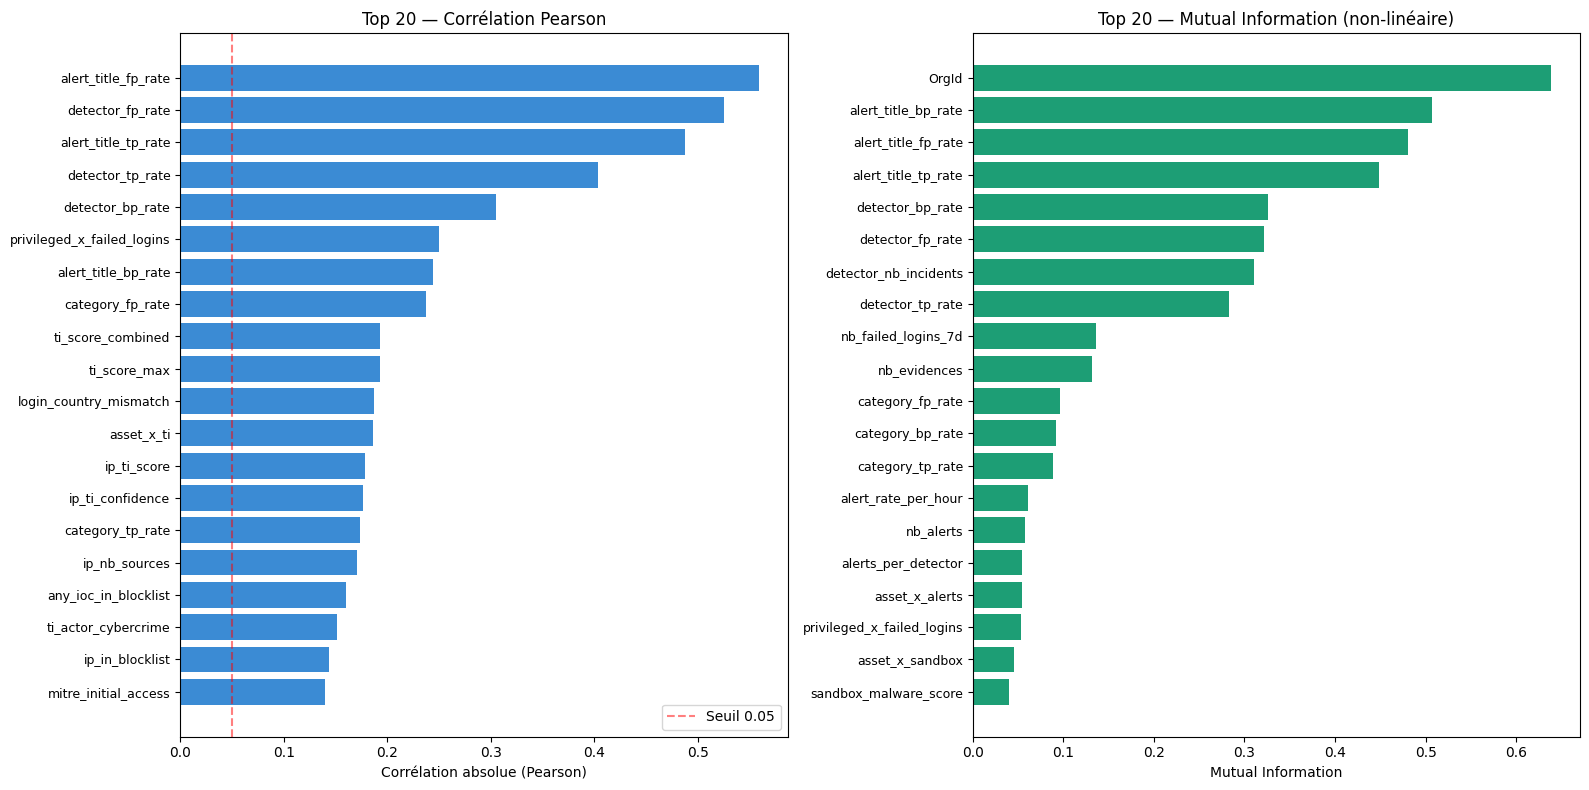

Figure sauvegardée : feature_importance_preliminary.png


In [294]:
# ── Visualisation : top 20 features ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Corrélation Pearson
top20_corr = corr_target.head(20)
axes[0].barh(range(len(top20_corr)), top20_corr.values, color='#3B8BD4')
axes[0].set_yticks(range(len(top20_corr)))
axes[0].set_yticklabels(top20_corr.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Corrélation absolue (Pearson)')
axes[0].set_title('Top 20 — Corrélation Pearson')
axes[0].axvline(0.05, color='red', linestyle='--', alpha=0.5, label='Seuil 0.05')
axes[0].legend()

# Mutual Information
top20_mi = mi_series.head(20)
axes[1].barh(range(len(top20_mi)), top20_mi.values, color='#1D9E75')
axes[1].set_yticks(range(len(top20_mi)))
axes[1].set_yticklabels(top20_mi.index, fontsize=9)
axes[1].invert_yaxis()
axes[1].set_xlabel('Mutual Information')
axes[1].set_title('Top 20 — Mutual Information (non-linéaire)')

plt.tight_layout()
plt.savefig(DATA_DIR / 'feature_importance_preliminary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : feature_importance_preliminary.png")

## 17. Sauvegarde

On sauvegarde le dataset ML final et les encodeurs (tables de taux par titre d'alerte,
catégorie, détecteur) pour pouvoir les réutiliser en inférence dans le `05_`.


In [295]:
import pickle

# ── Dataset ML final ───────────────────────────────────────────────────────────
feat_ml.to_csv(DATA_DIR / 'features_ml.csv', index=False)
feat_ml.to_parquet(DATA_DIR / 'features_ml.parquet', index=False)
print(f"✅ features_ml.csv sauvegardé : {feat_ml.shape[0]:,} incidents × {feat_ml.shape[1]} colonnes")
print(f"   Dont {len(feature_cols)} features ML + IncidentId + target")

# ── Encodeurs (tables de taux) ─────────────────────────────────────────────────
# Ces tables permettront d'encoder de nouveaux incidents en production
# sans avoir à recalculer les taux sur l'historique.
stats_title.to_parquet(DATA_DIR / 'encoder_alert_title.parquet')
stats_title.to_csv(DATA_DIR    / 'encoder_alert_title.csv')

stats_cat.to_parquet(DATA_DIR / 'encoder_category.parquet')
stats_cat.to_csv(DATA_DIR     / 'encoder_category.csv')

det_stats.to_parquet(DATA_DIR / 'encoder_detector.parquet')
det_stats.to_csv(DATA_DIR     / 'encoder_detector.csv')

# ── Taux globaux de fallback ────────────────────────────────────────────────────
global_rates = {'global_tp_rate': global_tp, 'global_fp_rate': global_fp,
                'global_bp_rate': global_bp}
with open(DATA_DIR / 'global_rates.pkl', 'wb') as f:
    pickle.dump(global_rates, f)
pd.DataFrame([global_rates]).to_csv(DATA_DIR / 'global_rates.csv', index=False)

print("\n✅ Encodeurs sauvegardés (alert_title, category, detector, global_rates)")
print("\n→ Prochaine étape : 03_ml_models.ipynb")

✅ features_ml.csv sauvegardé : 30,000 incidents × 86 colonnes
   Dont 84 features ML + IncidentId + target

✅ Encodeurs sauvegardés (alert_title, category, detector, global_rates)

→ Prochaine étape : 03_ml_models.ipynb


In [296]:
# ── Résumé des familles de features ───────────────────────────────────────────
familles = {
    'Alerte brute (compteurs + target encoding)':
        ['nb_alerts','nb_evidences','nb_categories','nb_detectors','nb_entity_types',
         'alert_title_tp_rate','alert_title_bp_rate','alert_title_fp_rate',
         'category_tp_rate','category_bp_rate','category_fp_rate'],
    'Temporelle':
        ['hour_of_day','day_of_week','is_weekend','is_business_hours','is_after_midnight',
         'incident_duration_min','alert_rate_per_hour','hour_sin','hour_cos','day_sin','day_cos'],
    'Propagation':
        ['accounts_per_device','ips_per_hour','alerts_per_detector','spread_score',
         'has_impacted_entity','nb_impacted_entities'],
    'Threat Intelligence':
        ['ip_ti_score','ip_in_blocklist','ip_nb_sources','ip_ti_confidence',
         'hash_ti_score','hash_in_blocklist','hash_nb_sources','hash_ti_confidence',
         'ti_score_max','ti_score_combined','any_ioc_in_blocklist',
         'ti_actor_APT','ti_actor_cybercrime','ti_actor_hacktivist'],
    'CMDB Device':
        ['asset_criticality_score','asset_patch_risk','asset_network_zone_risk',
         'asset_risk_score','days_since_last_patch','nb_vulnerabilities',
         'is_domain_controller','last_incident_days_ago','is_internet_exposed'],
    'CMDB User':
        ['user_criticality_score','is_privileged_account','account_inactive',
         'MFA_enabled','nb_failed_logins_7d','login_country_mismatch'],
    'Sandbox':
        ['sandbox_malware_score','sandbox_network_conns','sandbox_process_injection',
         'sandbox_c2_beaconing','sandbox_evasion','sandbox_lateral_movement',
         'sandbox_privilege_escalation','sandbox_dns_count','has_sandbox_analysis'],
    'Historique SOC (détecteur)':
        ['detector_tp_rate','detector_fp_rate','detector_bp_rate','detector_nb_incidents'],
    'MITRE ATT&CK':
        ['mitre_initial_access','mitre_execution','mitre_persistence',
         'mitre_credential_access','mitre_discovery','mitre_lateral_movement',
         'mitre_command_and_control','mitre_exfiltration','mitre_impact'],
    'Interactions CMDB × incident':
        ['asset_x_ti','asset_x_alerts','asset_x_sandbox','privileged_x_failed_logins'],
    'Contexte incident':
        ['has_ip','has_file','has_account','has_device','has_email',
         'has_threat_family','is_windows'],
}

total = 0
print(f"{'─'*65}")
for famille, cols in familles.items():
    present = [c for c in cols if c in feat_ml.columns]
    total  += len(present)
    print(f"  {famille} : {len(present)} features")
    print(f"    {', '.join(present)}")
    print()
print(f"{'─'*65}")
print(f"  TOTAL : {total} features ML (+ IncidentId + target)")

─────────────────────────────────────────────────────────────────
  Alerte brute (compteurs + target encoding) : 11 features
    nb_alerts, nb_evidences, nb_categories, nb_detectors, nb_entity_types, alert_title_tp_rate, alert_title_bp_rate, alert_title_fp_rate, category_tp_rate, category_bp_rate, category_fp_rate

  Temporelle : 11 features
    hour_of_day, day_of_week, is_weekend, is_business_hours, is_after_midnight, incident_duration_min, alert_rate_per_hour, hour_sin, hour_cos, day_sin, day_cos

  Propagation : 6 features
    accounts_per_device, ips_per_hour, alerts_per_detector, spread_score, has_impacted_entity, nb_impacted_entities

  Threat Intelligence : 14 features
    ip_ti_score, ip_in_blocklist, ip_nb_sources, ip_ti_confidence, hash_ti_score, hash_in_blocklist, hash_nb_sources, hash_ti_confidence, ti_score_max, ti_score_combined, any_ioc_in_blocklist, ti_actor_APT, ti_actor_cybercrime, ti_actor_hacktivist

  CMDB Device : 9 features
    asset_criticality_score, asset_pat